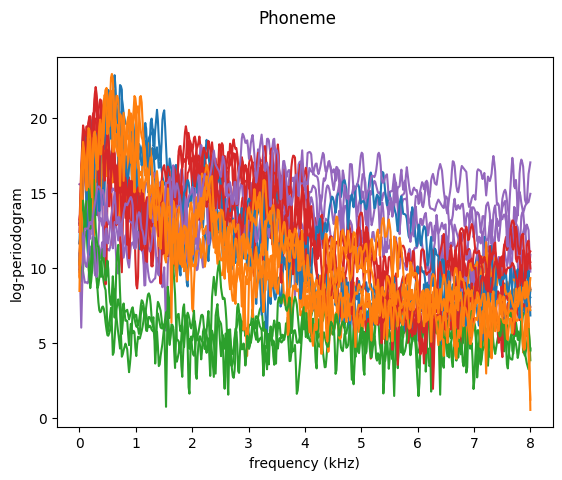

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from skfda.datasets import fetch_phoneme

X, y = fetch_phoneme(return_X_y=True)


n_plot = 20
X[:n_plot].plot(group=y)
plt.show()

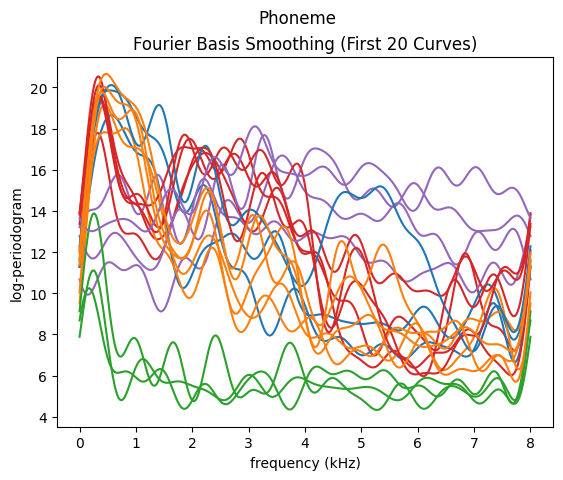

In [2]:
from skfda.representation.basis import FourierBasis
from skfda.preprocessing.smoothing import BasisSmoother

n_basis = 25  # Number of Fourier basis functions
fourier_basis = FourierBasis(domain_range=X.domain_range[0], n_basis=n_basis)

smoother = BasisSmoother(basis=fourier_basis, return_basis=True)
X_smooth = smoother.fit_transform(X)

# Plot the smoothed functions
n_plot = 20
X_smooth[:n_plot].plot(group=y[:n_plot])
plt.title("Fourier Basis Smoothing (First 20 Curves)")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_smooth,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y,
)

In [5]:
from scipy.stats import norm
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import GridSearchCV

from skfda.misc.metrics import BasisBasedDistance
from skfda.ml.classification import KNeighborsClassifier

classifier = KNeighborsClassifier(
    n_neighbors=5,
    metric=BasisBasedDistance(weights=np.logspace(0, 1, 25)),
)


def gaussian_bump(
    center: int,
    width: int,
) -> np.ndarray:
    x = np.linspace(0, 1, 25)
    return norm.pdf(x, loc=center, scale=width)


rng = np.random.default_rng(42)
random_perturbations = [
    np.abs(rng.normal(loc=1, scale=0.5, size=25)) for _ in range(2)
]

param_grid = {
    "metric__weights": [
        np.ones(25),  # Uniform
        np.linspace(10, 1, 25),  # Low
        np.linspace(1, 5, 25),  # High
        np.concatenate([np.linspace(1, 5, 12), np.linspace(5, 1, 13)]),  # Mid
        np.logspace(0, 2, 25)[::-1],  # Strong low emphasis
        np.logspace(0, 1, 25),  # Mild high emphasis
        gaussian_bump(0.2, 0.1),
        gaussian_bump(0.5, 0.1),
        gaussian_bump(0.8, 0.1),
        np.array([1 if 10 <= i < 15 else 0.1 for i in range(25)]),  # Mid band
        np.array([5 if i in {0, 1, 2} else 1 for i in range(25)]),  # Very low
        np.array([1 + np.sin(i * np.pi / 12) ** 2 for i in range(25)]),  # Wavy
        *random_perturbations,
    ],
}

grid = GridSearchCV(
    classifier,
    param_grid=param_grid,
    cv=5,
    scoring=make_scorer(accuracy_score),
    verbose=1,
)

# The grid search is too slow for a example. Uncomment it if you want, but it
# will take a while.

grid.fit(X_train, y_train)

print("Best weights:", grid.best_params_["metric__weights"])
print("Best CV accuracy:", grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best weights: [ 1.          1.10069417  1.21152766  1.33352143  1.46779927  1.6155981
  1.77827941  1.95734178  2.15443469  2.37137371  2.61015722  2.87298483
  3.16227766  3.48070059  3.83118685  4.21696503  4.64158883  5.10896977
  5.62341325  6.18965819  6.81292069  7.49894209  8.25404185  9.08517576
 10.        ]
Best CV accuracy: 0.9124566264323111
Test accuracy: 92.11%


In [6]:
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 92.11%
